<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml13_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MNIST 데이터셋 이미지 분류

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import image  # image.imsave(), image.imread() 함수

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Python에서 이미지 다루기

In [2]:
china = datasets.load_sample_image('china.jpg')

In [3]:
print(type(china))  #> numpy.ndarray

<class 'numpy.ndarray'>


In [4]:
china.shape

(427, 640, 3)

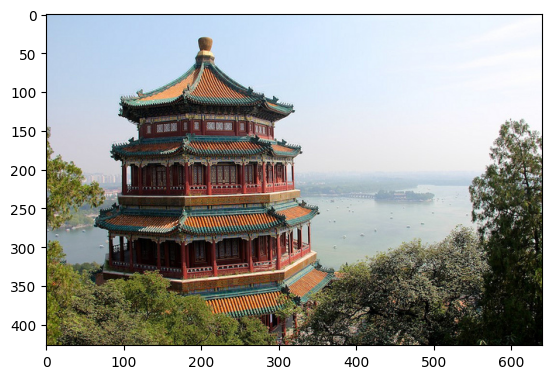

In [5]:
plt.imshow(china)
plt.show()

이미지 배열(numpy.ndarray)

*   흑백 이미지 - (height, width) 모양의 2차원 배열
*   컬러 이미지 - (height, width, channel) 모양의 3차원 배열
    *   불투명 이미지 - (height, width, 3) 모양의 3차원 배열
    *   투명도가 있는 이미지 - (height, width, 4) 모양의 3차원 배열
*   이미지 배열의 숫자 스케일
    *   0 ~ 255 정수 배열
    *   0.0 ~ 1.0 실수 배열


In [6]:
scaled = china / 255.0  # 최댓값을 1로 최솟값을 0으로 변환.

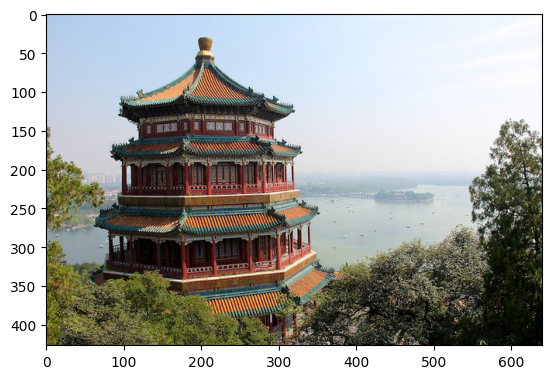

In [7]:
plt.imshow(scaled)
plt.show()

In [8]:
# pyplot.image.imsave(file_name, ndarray) -> 배열의 내용을 이미지 파일로 저장.
image.imsave('china_copy.jpg', china)

In [9]:
# pyplot.image.imread(file_name) -> 이미지 파일을 읽어서 ndarray를 리턴.
img = image.imread('china_copy.jpg')

array([[[173, 200, 229],
        [173, 200, 229],
        [173, 200, 229],
        ...,
        [250, 251, 255],
        [250, 251, 255],
        [250, 251, 255]],

       [[173, 200, 229],
        [173, 200, 229],
        [174, 201, 230],
        ...,
        [250, 251, 255],
        [251, 252, 255],
        [251, 252, 255]],

       [[173, 200, 229],
        [174, 201, 230],
        [174, 201, 230],
        ...,
        [251, 252, 255],
        [252, 253, 255],
        [252, 253, 255]],

       ...,

       [[ 88,  81,   1],
        [138, 132,  54],
        [132, 126,  52],
        ...,
        [ 44,  45,  40],
        [  3,   4,   0],
        [ 11,  12,   6]],

       [[115, 107,  32],
        [132, 124,  49],
        [115, 107,  35],
        ...,
        [ 26,  27,  22],
        [  6,   7,   1],
        [ 22,  23,  17]],

       [[122, 112,  41],
        [111, 103,  31],
        [102,  94,  22],
        ...,
        [ 31,  32,  27],
        [ 11,  12,   6],
        [ 19,  20,  14]]], dtype=uint8)
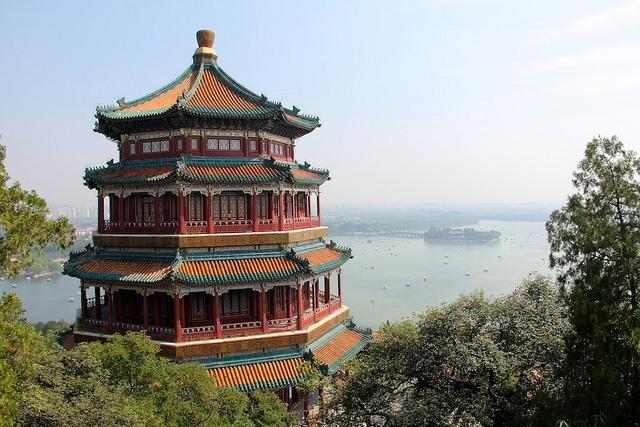

In [10]:
img

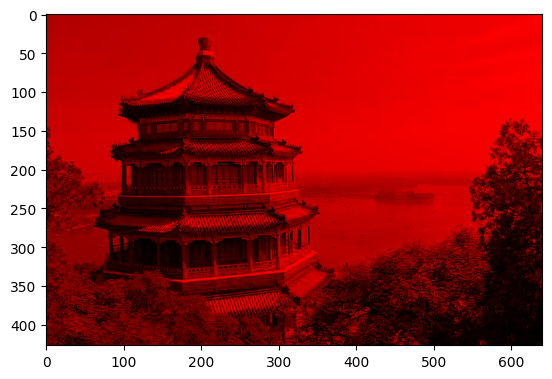

In [11]:
copy = img.copy()
copy[:, :, [1, 2]] = 0  # green, blue 값들을 0으로 설정 -> green, blue 색상을 제거
plt.imshow(copy)

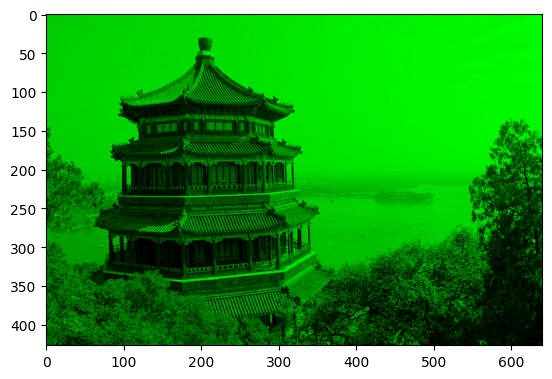

In [12]:
copy = img.copy()
copy[:, :, [0, 2]] = 0  # red, blue 색상을 제거
plt.imshow(copy)

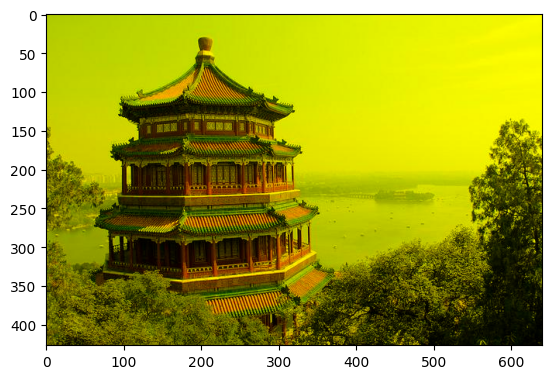

In [13]:
copy = img.copy()
copy[:, :, 2] = 0  # blue 색상만 제거
plt.imshow(copy)

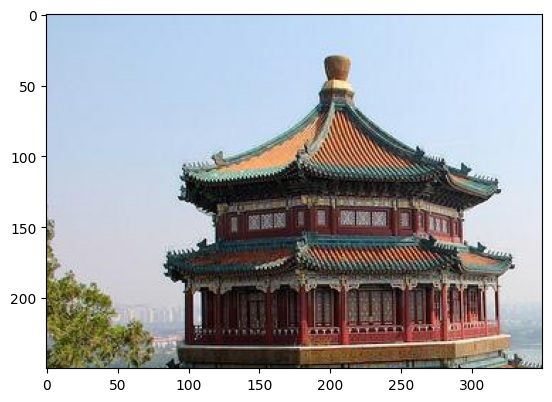

In [14]:
copy = img.copy()
result = copy[:250, :350, :]  # 이미지 자르기(crop)
plt.imshow(result)

# MNIST 데이터셋

70,000개의 숫자(0 ~ 9) 손글씨 흑백 이미지(28x28)들이 numpy.ndarray로 저장된 데이터 셋.

In [15]:
mnist = datasets.fetch_openml('mnist_784')

In [18]:
print(type(mnist))  #> Bunch

<class 'sklearn.utils._bunch.Bunch'>


In [19]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [20]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [23]:
x = mnist.data.values  # DataFrame -> ndarray
# type(x)  #> DataFrame
x[:5]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [24]:
x.shape  # (70_000, 784) = (n_samples, n_features)

(70000, 784)

In [27]:
y = mnist.target.values  # Series -> ndarray
# type(y)  #> Series
y[:5]

['5', '0', '4', '1', '9']
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [28]:
y.shape  # (70_000,) = (n_samples,)

(70000,)

In [29]:
np.max(x)

np.int64(255)

In [30]:
np.min(x)

np.int64(0)

이미지의 각 픽셀들은 0 ~ 255 정수 스케일로 만들어져 있음.

In [31]:
# 0 ~ 255 스케일을 0.0 ~ 1.0 스케일로 변환
x = x / 255.0

In [32]:
np.max(x), np.min(x)

(np.float64(1.0), np.float64(0.0))

# MNIST 데이터셋 시각화

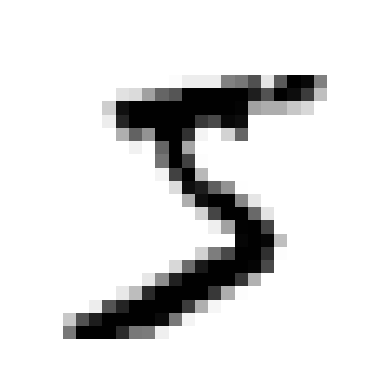

In [41]:
image_0 = x[0].reshape((28, 28))  # 28x28=784(pixel). (784,) -> (28, 28) 모양으로 변환.
plt.imshow(image_0, cmap=plt.cm.binary)
# cmap=plt.cm.gray: 0.0(black) ~ 1.0(white)
# cmap=plt.cm.binary: gray 스케일을 반전. 0.0(white) ~ 1.0(black)
plt.axis('off')
plt.show()

mnist 데이터셋에서 첫 100개의 이미지들을 10x10 Axes에 시각화.

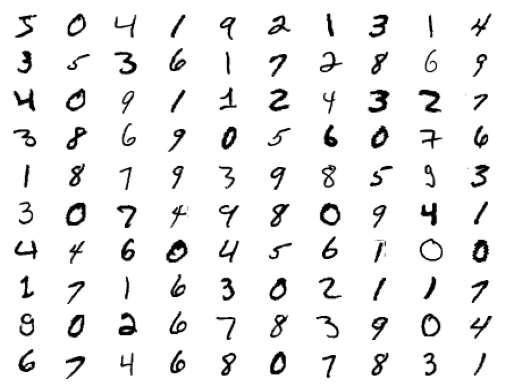

In [43]:
fig, axes = plt.subplots(nrows=10, ncols=10)

for i in range(10):
    for j in range(10):
        idx = i * 10 + j  # 0 ~ 99
        image = x[idx].reshape((28, 28))
        axes[i, j].imshow(image, cmap=plt.cm.binary)
        axes[i, j].axis('off')

plt.show()

In [45]:
# 타겟 배열 y에서 각 클래스의 비율
np.unique(y, return_counts=True)

(array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object),
 array([6903, 7877, 6990, 7141, 6824, 6313, 6876, 7293, 6825, 6958]))

# 훈련 셋, 검증 셋, 테스트 셋 나누기

In [46]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=10_000,
                                                    random_state=42,
                                                    stratify=y)

In [48]:
x_train.shape, x_test.shape

((60000, 784), (10000, 784))

In [49]:
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train,
                                            test_size=10_000,
                                            random_state=42,
                                            stratify=y_train)

In [51]:
x_tr.shape, x_val.shape

((50000, 784), (10000, 784))

# Logistic Regression

In [52]:
logistic = LogisticRegression(random_state=42, n_jobs=-1)

In [53]:
logistic.fit(X=x_tr, y=y_tr)  # ML 모델 훈련(데이터 학습)

LogisticRegression(n_jobs=-1, random_state=42)

Logistic Regression에서 모델 훈련(데이터 학습)은 Softmax 함수에서 사용할 선형 회귀식의 계수들(coefficients)과 절편들(intercepts)을 찾는 과정.

In [55]:
logistic.coef_.shape  # (10, 784) = (n_classes, n_features)

(10, 784)

In [57]:
logistic.intercept_.shape  # (10,) = (n_classes,)

(10,)

In [58]:
tr_pred = logistic.predict(X=x_tr)  # 훈련 셋 예측값

In [59]:
tr_pred[:10]

array(['4', '8', '4', '9', '7', '3', '5', '9', '1', '0'], dtype=object)

In [60]:
y_tr[:10]

['6', '8', '4', '9', '7', '3', '5', '9', '1', '0']
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [61]:
logistic.score(X=x_tr, y=y_tr)  # 훈련 셋 정확도

0.93576

In [68]:
logistic.score(X=x_val, y=y_val)  # 검증 셋 정확도

0.925

## 훈련 결과 분석

In [62]:
tr_cm = confusion_matrix(y_true=y_tr, y_pred=tr_pred)
print(tr_cm)

[[4804    1   12   10    5   32   23   10   27    7]
 [   1 5495   25   14    4   20    5   12   44    7]
 [  21   37 4583   59   45   24   51   50  101   21]
 [  10   22   90 4651    5  151   12   40   81   39]
 [  10   15   28    7 4590    5   37   21   26  135]
 [  35   15   38  127   41 4050   62   14   95   32]
 [  18   13   30    3   30   58 4738    4   16    2]
 [   7   18   58   23   32    9    3 4914   12  133]
 [  23   78   50  106   14  114   33   11 4401   45]
 [  20   21    8   62  111   22    2  126   36 4562]]


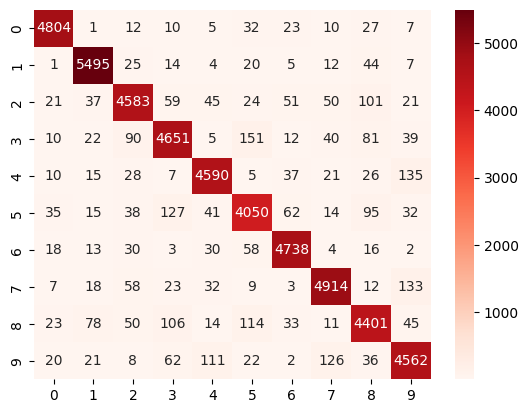

In [64]:
sns.heatmap(data=tr_cm, cmap='Reds', annot=True, fmt='d')
plt.show()

예측이 틀린 샘플들의 위치를 진한 색깔로 표현하기 위해서 혼동 행렬의 대각선을 0으로 세팅.

In [65]:
np.fill_diagonal(tr_cm, 0)

In [66]:
tr_cm

array([[  0,   1,  12,  10,   5,  32,  23,  10,  27,   7],
       [  1,   0,  25,  14,   4,  20,   5,  12,  44,   7],
       [ 21,  37,   0,  59,  45,  24,  51,  50, 101,  21],
       [ 10,  22,  90,   0,   5, 151,  12,  40,  81,  39],
       [ 10,  15,  28,   7,   0,   5,  37,  21,  26, 135],
       [ 35,  15,  38, 127,  41,   0,  62,  14,  95,  32],
       [ 18,  13,  30,   3,  30,  58,   0,   4,  16,   2],
       [  7,  18,  58,  23,  32,   9,   3,   0,  12, 133],
       [ 23,  78,  50, 106,  14, 114,  33,  11,   0,  45],
       [ 20,  21,   8,  62, 111,  22,   2, 126,  36,   0]])

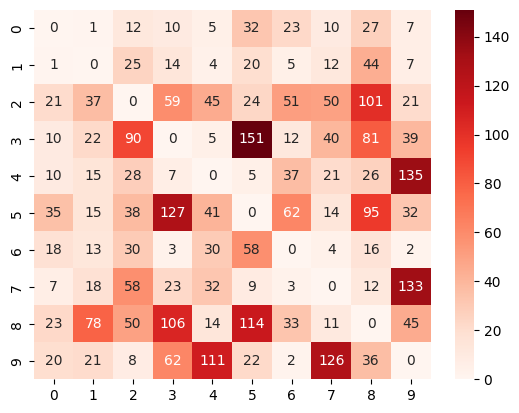

In [67]:
sns.heatmap(data=tr_cm, cmap='Reds', annot=True, fmt='d')
plt.show()

예측이 틀린 훈련 셋(x_tr) 샘플 100개를 시각화

In [70]:
x_wrong = x_tr[y_tr != tr_pred]  # 예측이 틀린 샘플들

In [71]:
x_wrong.shape

(3212, 784)

In [72]:
y_wrong = y_tr[y_tr != tr_pred]  # 예측이 틀린 샘플들의 실제 레이블(클래스)
y_wrong[:10]

['6', '8', '2', '5', '3', '8', '2', '3', '9', '2']
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [73]:
pr_wrong = tr_pred[y_tr != tr_pred]  # 예측이 틀린 샘플들의 예측값
pr_wrong[:10]

array(['4', '1', '6', '9', '2', '5', '3', '9', '5', '7'], dtype=object)

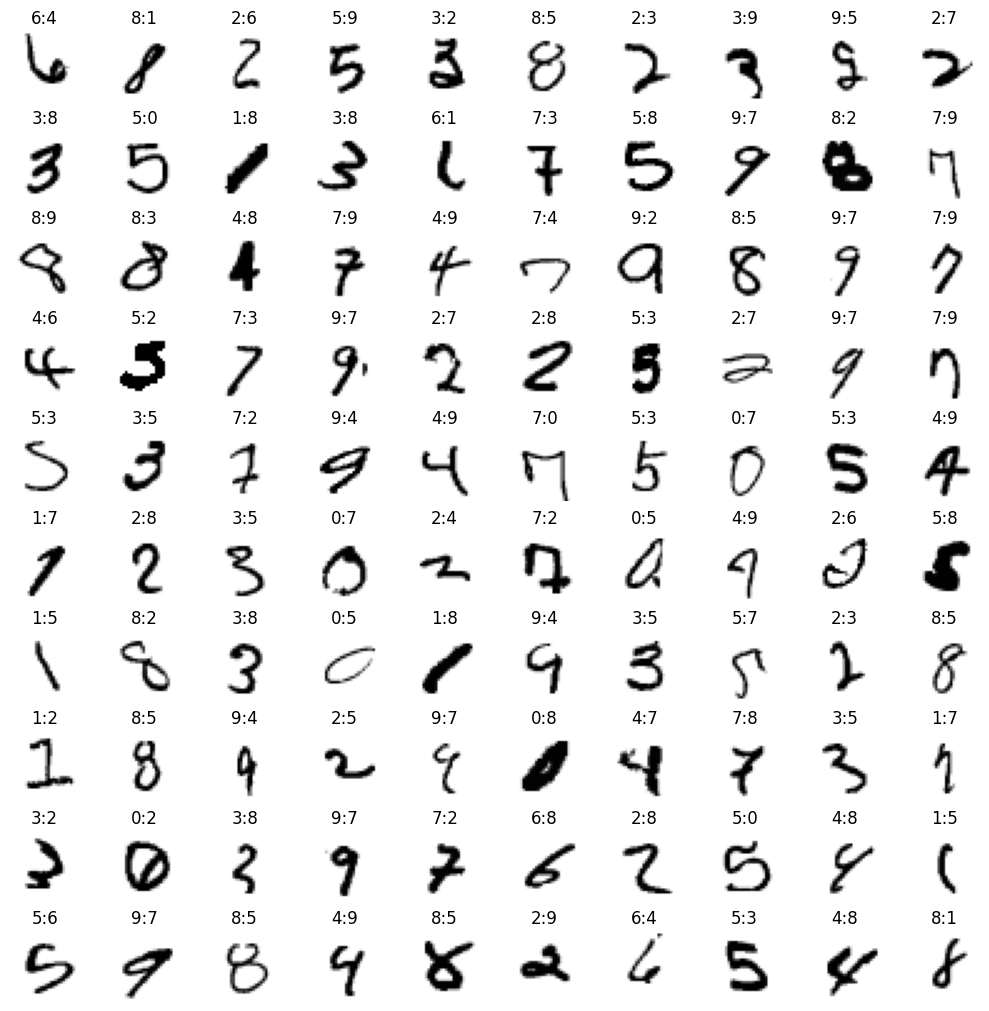

In [75]:
fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(10, 10), layout='constrained')
for i in range(10):
    for j in range(10):
        idx = i * 10 + j
        image = x_wrong[idx].reshape((28, 28))
        axes[i, j].imshow(image, cmap=plt.cm.binary)
        axes[i, j].axis('off')
        axes[i, j].set_title(f'{y_wrong[idx]}:{pr_wrong[idx]}')

plt.show()

# K-Nearest Neighbors

In [76]:
knn = KNeighborsClassifier(n_jobs=-1)

In [77]:
knn.fit(X=x_tr, y=y_tr)

KNeighborsClassifier(n_jobs=-1)

KNN은 데이터 학습(훈련) 시간이 거의 없음.

KNN은 예측할 때 시간이 오래 걸림.

In [79]:
knn.score(X=x_tr, y=y_tr)  # 훈련 셋 정확도
# (1) predict(X=x_tr) --> (2) real == predictions  --> 정확도

0.98

In [80]:
knn.score(X=x_val, y=y_val)  # 검증 셋 정확도

0.9723